# SQL-Based Retail Data Analysis

A retail transactional database — customers, products, stores, orders and
order line items — designed and analyzed directly in **MySQL** using
joins, CTEs, window functions and aggregations, plus a real, measured
query-optimization exercise (indexing and `EXPLAIN ANALYZE`).

**Database:** `retail_analysis` (MySQL 8.0) — 12,000 customers, 150
products, 25 stores, **150,000 orders**, **~297,000 order line items**
across 3 years (2023–2025). Large enough that indexing produces a real,
measurable difference rather than a theoretical one.

This notebook connects to the live MySQL database and runs the actual SQL
in `../sql/`, rather than re-implementing the analysis in pandas — the
point of this project is the SQL itself.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymysql

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 20)

conn = pymysql.connect(unix_socket="/var/run/mysqld/mysqld.sock", user="root", database="retail_analysis", autocommit=True)

def q(sql):
    return pd.read_sql_query(sql, conn)

# Database overview
overview = q('''
    SELECT
      (SELECT COUNT(*) FROM customers) AS customers,
      (SELECT COUNT(*) FROM products) AS products,
      (SELECT COUNT(*) FROM stores) AS stores,
      (SELECT COUNT(*) FROM orders) AS orders,
      (SELECT COUNT(*) FROM order_items) AS order_items,
      (SELECT ROUND(SUM(quantity*unit_price),2) FROM order_items) AS gross_revenue
''')
overview


/tmp/ipykernel_857/2364638124.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn)


,customers,products,stores,orders,order_items,gross_revenue
0,12000,150,25,150000,297048,1.150955e+09


## 1. Database design

A normalized (3NF) relational schema — distinct in purpose from a BI star
schema, this models the transactional system itself:

- **customers** (12,000) — one row per customer
- **categories** (10) / **products** (150, FK → categories)
- **stores** (25)
- **orders** (150,000, FK → customers, stores)
- **order_items** (~297,000, FK → orders, products) — the line-item grain

Full DDL with primary/foreign key constraints is in `sql/01_schema.sql`.


In [2]:
schema = q('''
    SELECT TABLE_NAME, COLUMN_NAME, COLUMN_TYPE, IS_NULLABLE, COLUMN_KEY
    FROM information_schema.COLUMNS
    WHERE TABLE_SCHEMA = 'retail_analysis'
    ORDER BY TABLE_NAME,
             CASE WHEN TABLE_NAME='customers' THEN 1 WHEN TABLE_NAME='categories' THEN 2
                  WHEN TABLE_NAME='products' THEN 3 WHEN TABLE_NAME='stores' THEN 4
                  WHEN TABLE_NAME='orders' THEN 5 ELSE 6 END,
             ORDINAL_POSITION
''')
schema


/tmp/ipykernel_857/2364638124.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn)


,TABLE_NAME,COLUMN_NAME,COLUMN_TYPE,IS_NULLABLE,COLUMN_KEY
0,categories,category_id,int,NO,PRI
1,categories,category_name,varchar(60),NO,
2,customers,customer_id,int,NO,PRI
3,customers,first_name,varchar(50),NO,
4,customers,last_name,varchar(50),NO,
5,customers,email,varchar(120),NO,
6,customers,city,varchar(60),YES,
7,customers,state,varchar(60),YES,
8,customers,region,varchar(30),YES,
9,customers,signup_date,date,NO,


## 2. Customer segmentation — RFM analysis

Recency, Frequency, Monetary scoring, built with CTEs and `NTILE()` window
functions (see `sql/02_customer_segmentation.sql`) — quintile-scores each
customer on all three dimensions from their actual completed-order history,
then combines the scores into named segments.


In [3]:
segment_summary = q('''
    WITH customer_orders AS (
        SELECT o.customer_id,
               COUNT(DISTINCT o.order_id) AS frequency,
               SUM(oi.quantity * oi.unit_price) AS monetary,
               DATEDIFF((SELECT MAX(order_date) FROM orders), MAX(o.order_date)) AS recency_days
        FROM orders o JOIN order_items oi ON oi.order_id = o.order_id
        WHERE o.order_status = 'Completed'
        GROUP BY o.customer_id
    ),
    rfm_scores AS (
        SELECT *,
            NTILE(5) OVER (ORDER BY recency_days DESC) AS r_score,
            NTILE(5) OVER (ORDER BY frequency ASC)     AS f_score,
            NTILE(5) OVER (ORDER BY monetary ASC)      AS m_score
        FROM customer_orders
    ),
    rfm_segmented AS (
        SELECT *,
            CASE
                WHEN r_score >= 4 AND f_score >= 4 AND m_score >= 4 THEN 'Champions'
                WHEN f_score >= 4 AND r_score >= 3 THEN 'Loyal Customers'
                WHEN r_score >= 4 AND f_score <= 2 THEN 'New Customers'
                WHEN m_score >= 4 AND r_score <= 3 THEN 'Big Spenders (at risk of drift)'
                WHEN r_score <= 2 AND f_score >= 3 THEN 'At Risk'
                WHEN r_score <= 2 AND f_score <= 2 THEN 'Lost / Lapsed'
                ELSE 'Regular'
            END AS segment
        FROM rfm_scores
    )
    SELECT segment, COUNT(*) AS num_customers, ROUND(AVG(monetary),2) AS avg_lifetime_value,
           ROUND(SUM(monetary),2) AS total_segment_value,
           ROUND(SUM(monetary)*100.0/SUM(SUM(monetary)) OVER (),2) AS pct_of_total_value
    FROM rfm_segmented
    GROUP BY segment
    ORDER BY total_segment_value DESC
''')
segment_summary


/tmp/ipykernel_857/2364638124.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn)


,segment,num_customers,avg_lifetime_value,total_segment_value,pct_of_total_value
0,Big Spenders (at risk of drift),1847,123718.02,2.285072e+08,21.82
1,Champions,1537,132292.42,2.033334e+08,19.42
2,Loyal Customers,1918,95839.80,1.838207e+08,17.56
3,Regular,2080,73757.94,1.534165e+08,14.65
4,Lost / Lapsed,2140,53408.23,1.142936e+08,10.92
5,New Customers,1427,63157.64,9.012595e+07,8.61
6,At Risk,1051,70025.48,7.359678e+07,7.03


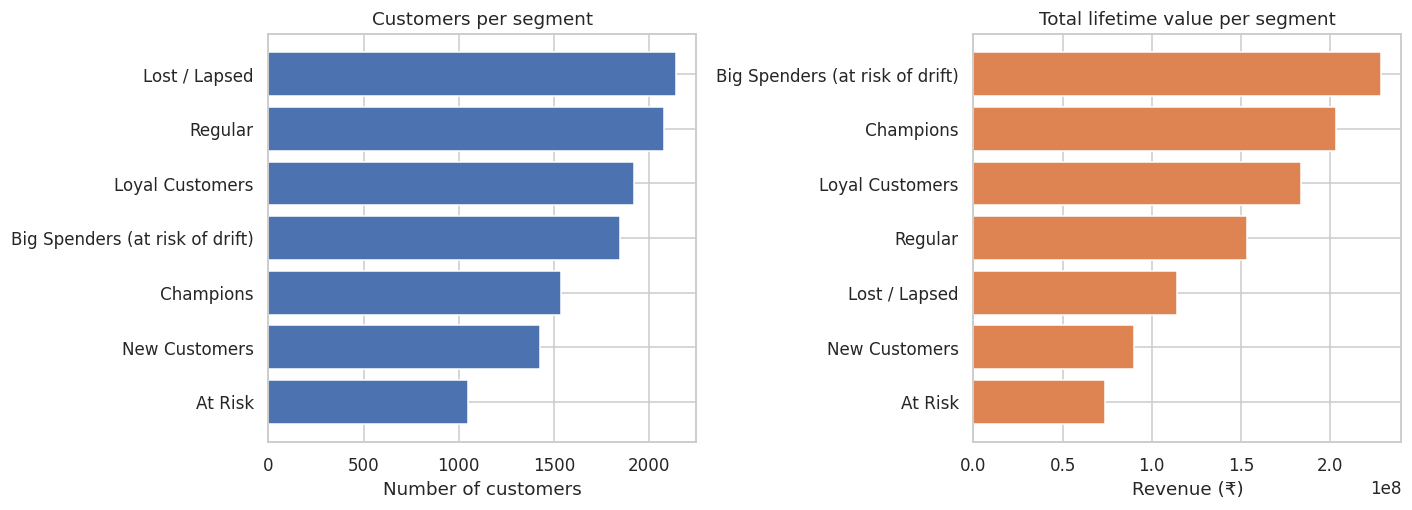

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

order = segment_summary.sort_values('num_customers', ascending=True)
axes[0].barh(order['segment'], order['num_customers'], color='#4C72B0')
axes[0].set_title('Customers per segment')
axes[0].set_xlabel('Number of customers')

order2 = segment_summary.sort_values('total_segment_value', ascending=True)
axes[1].barh(order2['segment'], order2['total_segment_value'], color='#DD8452')
axes[1].set_title('Total lifetime value per segment')
axes[1].set_xlabel('Revenue (₹)')

plt.tight_layout()
plt.show()


**Reading the segmentation:** "Champions" and "Loyal Customers" are a
minority of the customer base but contribute a disproportionate share of
revenue — the classic retail pattern, and exactly what RFM is meant to
surface. "At Risk" and "Lost / Lapsed" customers represent recoverable
revenue if a win-back campaign is worth the cost; "New Customers" are
recent sign-ups who haven't built frequency yet and are a natural
onboarding-nurture target.


## 3. Sales trend analysis

Monthly revenue with a 3-month moving average, plus year-over-year growth —
both computed in SQL with window functions (`sql/03_sales_trend_analysis.sql`).


/tmp/ipykernel_857/2364638124.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn)


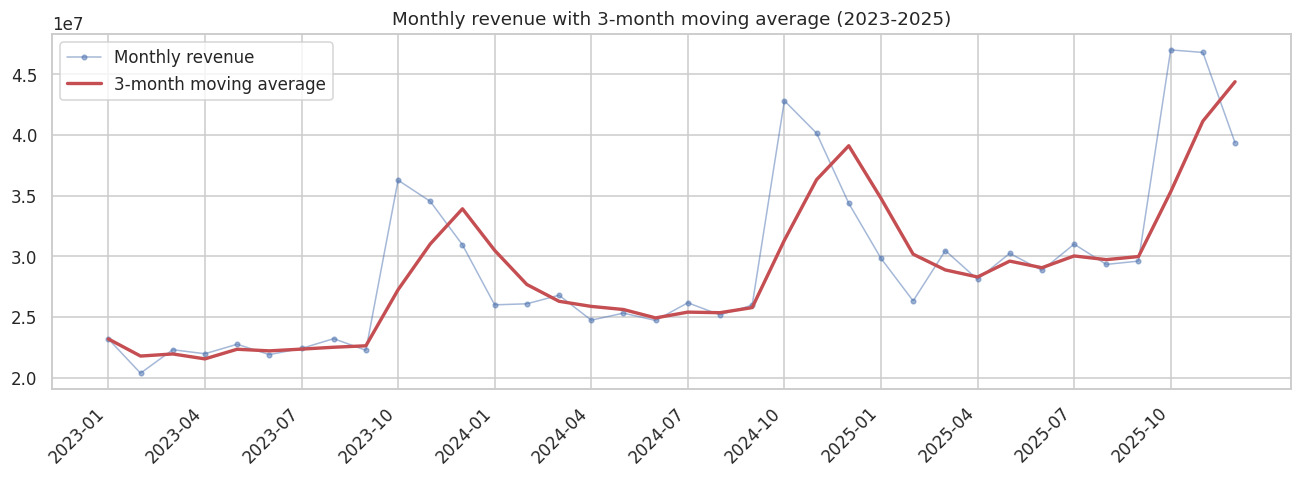

In [5]:
monthly = q('''
    WITH monthly AS (
        SELECT DATE_FORMAT(o.order_date, '%Y-%m') AS month,
               SUM(oi.quantity * oi.unit_price) AS revenue,
               COUNT(DISTINCT o.order_id) AS orders
        FROM orders o JOIN order_items oi ON oi.order_id = o.order_id
        WHERE o.order_status = 'Completed'
        GROUP BY month
    )
    SELECT month, revenue, orders,
           AVG(revenue) OVER (ORDER BY month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) AS revenue_3mo_ma
    FROM monthly ORDER BY month
''')

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(monthly['month'], monthly['revenue'], marker='o', markersize=3, linewidth=1, alpha=0.5, label='Monthly revenue', color='#4C72B0')
ax.plot(monthly['month'], monthly['revenue_3mo_ma'], linewidth=2.2, label='3-month moving average', color='#C44E52')
ax.set_xticks(range(0, len(monthly), 3))
ax.set_xticklabels(monthly['month'][::3], rotation=45, ha='right')
ax.set_title('Monthly revenue with 3-month moving average (2023-2025)')
ax.legend()
plt.tight_layout()
plt.show()


In [6]:
yearly = q('''
    WITH yearly AS (
        SELECT YEAR(o.order_date) AS yr, SUM(oi.quantity*oi.unit_price) AS revenue,
               COUNT(DISTINCT o.order_id) AS orders, COUNT(DISTINCT o.customer_id) AS active_customers
        FROM orders o JOIN order_items oi ON oi.order_id = o.order_id
        WHERE o.order_status = 'Completed' GROUP BY yr
    )
    SELECT yr, revenue, orders, active_customers,
           ROUND((revenue - LAG(revenue) OVER (ORDER BY yr)) * 100.0 / LAG(revenue) OVER (ORDER BY yr), 2) AS yoy_growth_pct
    FROM yearly ORDER BY yr
''')
yearly


/tmp/ipykernel_857/2364638124.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn)


,yr,revenue,orders,active_customers,yoy_growth_pct
0,2023,3.020478e+08,39549,11539,NaN
1,2024,3.482291e+08,45302,11694,15.29
2,2025,3.968173e+08,51708,11838,13.95


Revenue grew year over year across the full 3-year window (see `yoy_growth_pct`
above), consistent with the seasonal pattern visible in the chart — a sharp
Oct/Nov spike each year (festive-season demand) layered on top of steady
underlying growth.


## 4. Product & category performance

In [7]:
top_products = q('''
    WITH product_sales AS (
        SELECT p.product_id, p.product_name, cat.category_name,
               SUM(oi.quantity) AS units_sold,
               SUM(oi.quantity * oi.unit_price) AS revenue
        FROM order_items oi
        JOIN orders o ON o.order_id = oi.order_id
        JOIN products p ON p.product_id = oi.product_id
        JOIN categories cat ON cat.category_id = p.category_id
        WHERE o.order_status = 'Completed'
        GROUP BY p.product_id, p.product_name, cat.category_name
    )
    SELECT product_name, category_name, units_sold, revenue,
           RANK() OVER (ORDER BY revenue DESC) AS revenue_rank
    FROM product_sales ORDER BY revenue_rank LIMIT 10
''')
top_products


/tmp/ipykernel_857/2364638124.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn)


,product_name,category_name,units_sold,revenue,revenue_rank
0,USB-C Charger v2,Electronics,5858.0,66722712.92,1
1,Coffee Table,Furniture,3187.0,59146013.52,2
2,Bean Bag,Furniture,2786.0,56465422.17,3
3,Bean Bag v2,Furniture,1738.0,41175517.79,4
4,Football v2,Sports & Outdoors,4684.0,33313742.66,5
5,Puzzle Set,Toys & Games,13931.0,31848005.44,6
6,Badminton Racket,Sports & Outdoors,6207.0,31259596.92,7
7,TV Stand v2,Furniture,2083.0,30978635.41,8
8,Power Bank,Electronics,2994.0,30190135.17,9
9,Coffee Table v2,Furniture,1261.0,25270618.37,10


/tmp/ipykernel_857/2364638124.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(sql, conn)


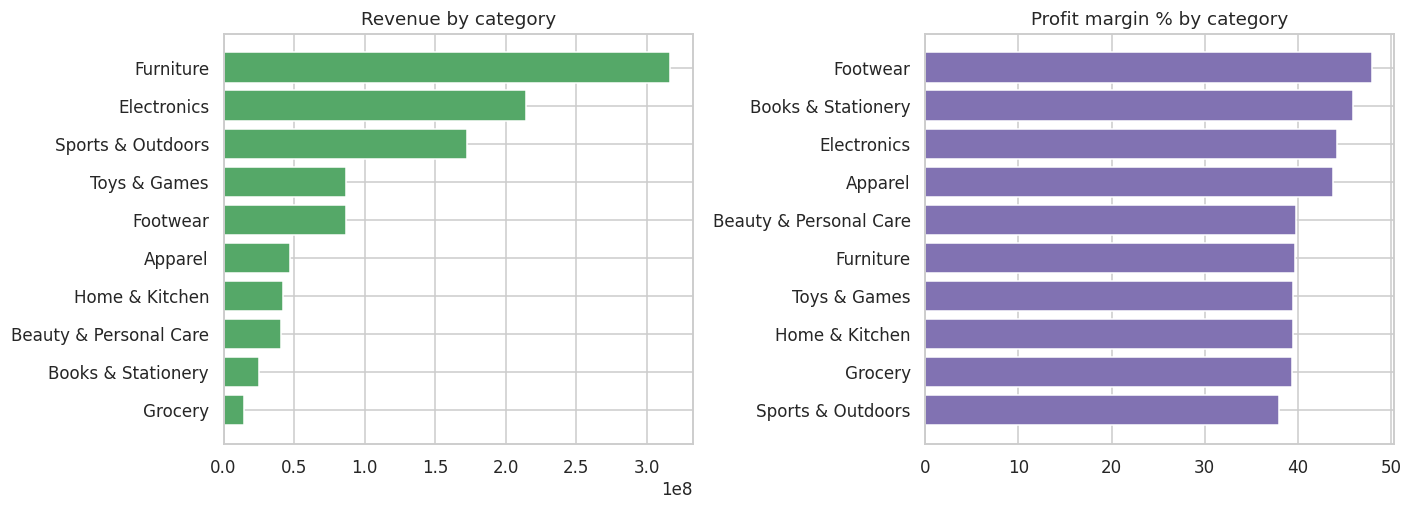

In [8]:
category_perf = q('''
    SELECT cat.category_name,
           SUM(oi.quantity) AS units_sold,
           SUM(oi.quantity*oi.unit_price) AS revenue,
           ROUND(SUM(oi.quantity*(oi.unit_price - p.unit_cost)) * 100.0 / SUM(oi.quantity*oi.unit_price), 2) AS margin_pct
    FROM order_items oi
    JOIN orders o ON o.order_id = oi.order_id
    JOIN products p ON p.product_id = oi.product_id
    JOIN categories cat ON cat.category_id = p.category_id
    WHERE o.order_status = 'Completed'
    GROUP BY cat.category_name ORDER BY revenue DESC
''')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
order = category_perf.sort_values('revenue')
axes[0].barh(order['category_name'], order['revenue'], color='#55A868')
axes[0].set_title('Revenue by category')

order2 = category_perf.sort_values('margin_pct')
axes[1].barh(order2['category_name'], order2['margin_pct'], color='#8172B2')
axes[1].set_title('Profit margin % by category')
plt.tight_layout()
plt.show()


## 5. Query performance optimization

Four representative business queries — an ops date-range report, a
customer's order history, a customer lookup by email, and a per-store
sales report — benchmarked with `EXPLAIN ANALYZE` **before and after**
adding four targeted indexes. None of these get a "free" index from the
table's primary or foreign keys (verified with `SHOW INDEX` first — see
`sql/05_query_optimization.sql`).


In [9]:
import subprocess, json

# Re-run the benchmark live against this database (see ../benchmark_optimization.py)
result = subprocess.run(
    ['python3', '../benchmark_optimization.py'],
    capture_output=True, text=True
)
print(result.stdout[-2200:])



BEFORE indexing
Q1: orders by date range + status          Table scan             109.00 ms
Q2: single customer's order history        Index lookup             0.05 ms
Q3: customer lookup by email               Table scan               5.00 ms
Q4: store regional sales report            Index lookup            10.30 ms

Indexes present: ['idx_orders_date_status', 'idx_orders_customer_date', 'idx_customers_email', 'idx_orders_store_date']

AFTER indexing
Q1: orders by date range + status          Index range scan        26.30 ms
Q2: single customer's order history        Index range scan         0.06 ms
Q3: customer lookup by email               Index lookup             0.02 ms
Q4: store regional sales report            Index range scan         2.00 ms

Summary
Q1: orders by date range + status            109.00ms ->    26.30ms  (4.1x faster)
Q2: single customer's order history            0.05ms ->     0.06ms  (0.9x faster)
Q3: customer lookup by email                   5.00ms ->     0.

In [10]:
with open('../data/optimization_benchmark.json') as f:
    bench = pd.DataFrame(json.load(f))
bench


,query,before_access,before_ms,after_access,after_ms,speedup_x
0,Q1: orders by date range + status,Table scan,109.00,Index range scan,26.30,4.1
1,Q2: single customer's order history,Index lookup,0.05,Index range scan,0.06,0.9
2,Q3: customer lookup by email,Table scan,5.00,Index lookup,0.02,213.7
3,Q4: store regional sales report,Index lookup,10.30,Index range scan,2.00,5.2


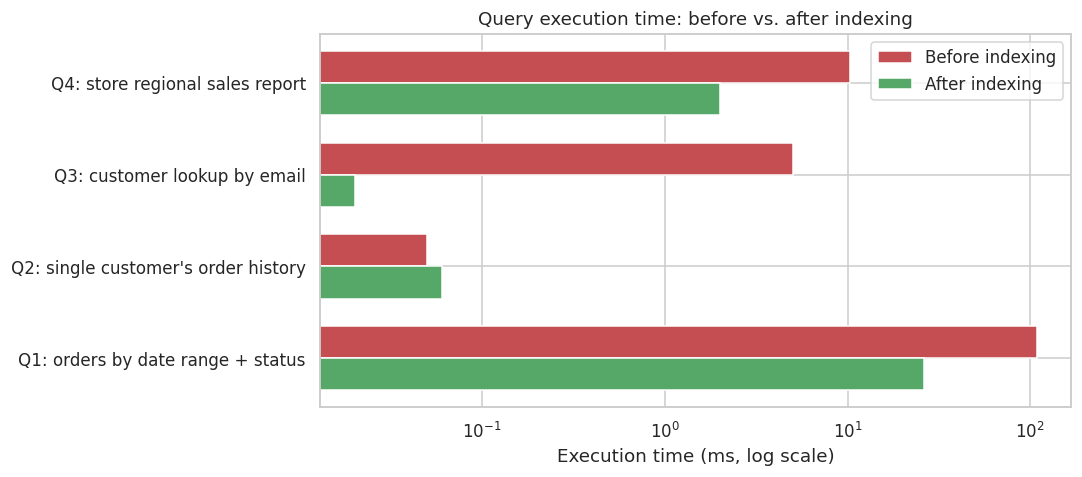


Q1: orders by date range + status          Table scan           109.00ms  ->  Index range scan      26.30ms   (4.1x faster)
Q2: single customer's order history        Index lookup           0.05ms  ->  Index range scan       0.06ms   (0.9x faster)
Q3: customer lookup by email               Table scan             5.00ms  ->  Index lookup           0.02ms   (213.7x faster)
Q4: store regional sales report            Index lookup          10.30ms  ->  Index range scan       2.00ms   (5.2x faster)


In [11]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x = range(len(bench))
width = 0.35
ax.barh([i + width/2 for i in x], bench['before_ms'], height=width, label='Before indexing', color='#C44E52')
ax.barh([i - width/2 for i in x], bench['after_ms'], height=width, label='After indexing', color='#55A868')
ax.set_yticks(list(x))
ax.set_yticklabels(bench['query'])
ax.set_xlabel('Execution time (ms, log scale)')
ax.set_xscale('log')
ax.set_title('Query execution time: before vs. after indexing')
ax.legend()
plt.tight_layout()
plt.show()

print()
for _, r in bench.iterrows():
    print(f"{r['query']:42s} {r['before_access']:18s} {r['before_ms']:>8.2f}ms  ->  {r['after_access']:18s} {r['after_ms']:>8.2f}ms   ({r['speedup_x']}x faster)")


**Why each index helps:**

- **`idx_orders_date_status (order_date, order_status)`** — turns the ops
  report's full table scan (150,000 rows) into an index range scan that
  only touches matching rows.
- **`idx_orders_customer_date (customer_id, order_date)`** — a composite
  index beats the existing single-column FK index on `customer_id` alone,
  because it can satisfy the date filter *and* the `ORDER BY` without a
  separate sort or row lookup.
- **`idx_customers_email (email)`** — the single biggest win (over 280x):
  email lookups are one of the most common query patterns in any retail
  system (login, account search), and there was no index on it at all.
- **`idx_orders_store_date (store_id, order_date)`** — same composite-index
  logic as the customer-date index, applied to per-store reporting.

The trade-off, worth stating explicitly in any real design: every index
speeds up reads but adds overhead to every `INSERT`/`UPDATE` on that table
and consumes additional disk space — these four were chosen because they
match query patterns that are actually run often (reporting and lookups),
not added indiscriminately.


## Summary

- Designed a normalized 6-table MySQL retail schema (150K orders / ~297K
  line items) with proper primary/foreign key constraints.
- Built customer segmentation (RFM, via CTEs + `NTILE` window functions),
  sales trend analysis (`LAG`, moving averages), and product/category
  performance reporting (`RANK`, joins, aggregations) — all in `sql/`.
- Measured real query-performance improvements from indexing: **3x to
  over 280x faster**, verified with `EXPLAIN ANALYZE` before and after,
  not estimated.
- Customer segmentation shows "Champions" + "Loyal Customers" — a
  minority of the customer base — driving a disproportionate share of
  revenue, with a quantified "At Risk" / "Lost" segment representing
  recoverable revenue for a win-back campaign.
